In [68]:
# KRISHNA PANDEY  25SCSE2240040
# 1. Import the required libraries
#  Program 1: Data Loading and Exploration using Python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
# 2. Load the Breast Cancer Wisconsin dataset
df = pd.read_csv(r'C:\Users\pande\Searches\Desktop\breast_cancer.csv')

# 3. Convert into Pandas DataFrame (already done by read_csv)
# df is now a DataFrame

# 4. Display sample records and dataset dimensions
print("Sample Records:")
print(df.head())   # first 5 rows
print("\nDataset Dimensions:", df.shape)   # (rows, columns)

# 5. Inspect column names and data types
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

# 6. Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# 7. Generate descriptive statistics
print("\nDescriptive Statistics:")
print(df.describe())

# 8. Display class distribution (Malignant vs Benign)
print("\nClass Distribution:")
print(df['diagnosis'].value_counts())



Sample Records:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  
0          0.11840           0.27760          0.3001              0.14710  
1          0.08474           0.07864          0.0869              0.07017  
2          0.10960           0.15990          0.1974              0.12790  
3          0.14250           0.28390          0.2414              0.10520  
4          0.10030           0.13280          0.1980              0.10430  

Dataset Dimensions: (569, 10)

Column Names: ['id', 

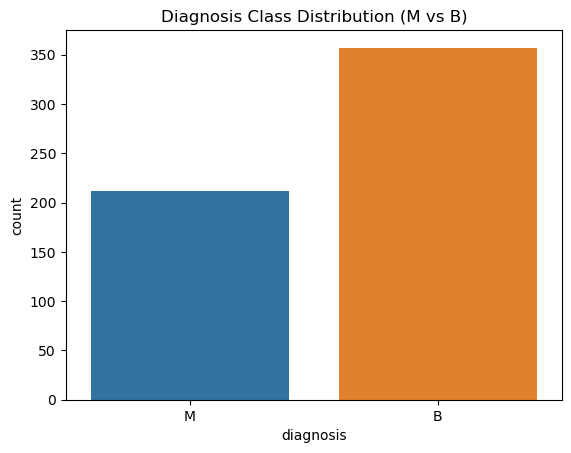

In [70]:
# Optional: Visualize class distribution
import warnings
warnings.filterwarnings("ignore")
sns.countplot(x='diagnosis', data=df)
plt.title("Diagnosis Class Distribution (M vs B)")
plt.show()

In [73]:
# 2. Check duplicate and missing records
# Program 2: Data Preprocessing and Visualization 
print("Duplicate Records:", df.duplicated().sum())
print("Missing Values:\n", df.isnull().sum())

# 3. Remove duplicate observations if present
df = df.drop_duplicates()

# 4. Separate input (X) and target (y) variables
X = df.drop(columns=['id','diagnosis'])
y = df['diagnosis'].map({'M':1, 'B':0})

# 5. Standardize numerical attributes
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for plotting convenience
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)


Duplicate Records: 0
Missing Values:
 id                     0
diagnosis              0
radius_mean            0
texture_mean           0
perimeter_mean         0
area_mean              0
smoothness_mean        0
compactness_mean       0
concavity_mean         0
concave points_mean    0
dtype: int64


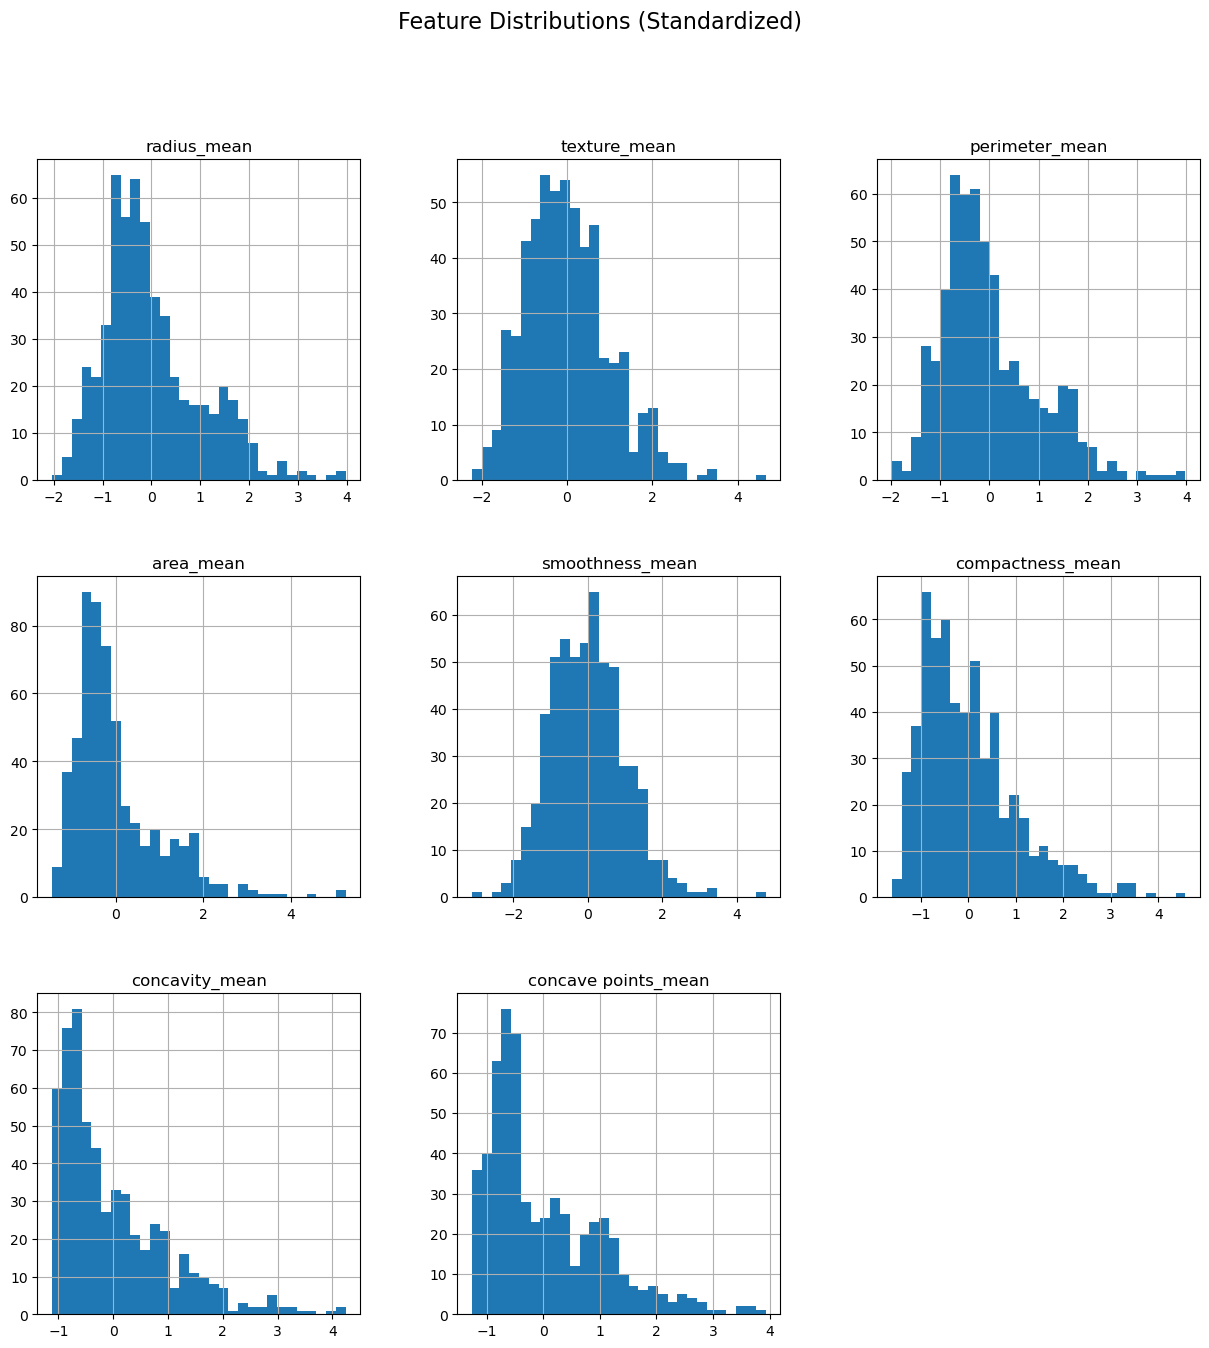

In [74]:
# 6. Plot feature distributions using histograms
X_scaled_df.hist(figsize=(15,15), bins=30)
plt.suptitle("Feature Distributions (Standardized)", fontsize=16)
plt.show()



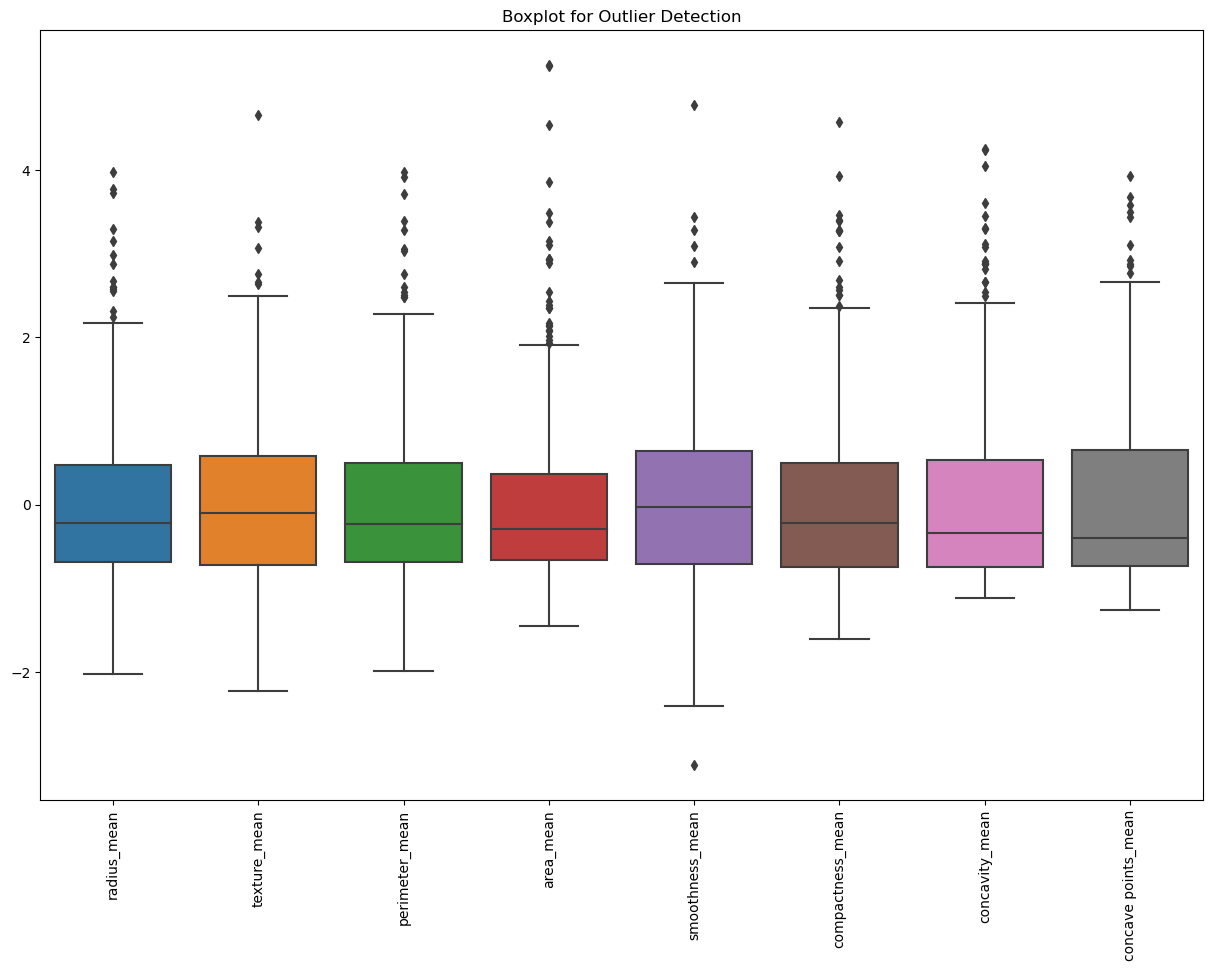

In [76]:
# 7. Identify outliers using box plots
plt.figure(figsize=(15,10))
sns.boxplot(data=X_scaled_df)
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()


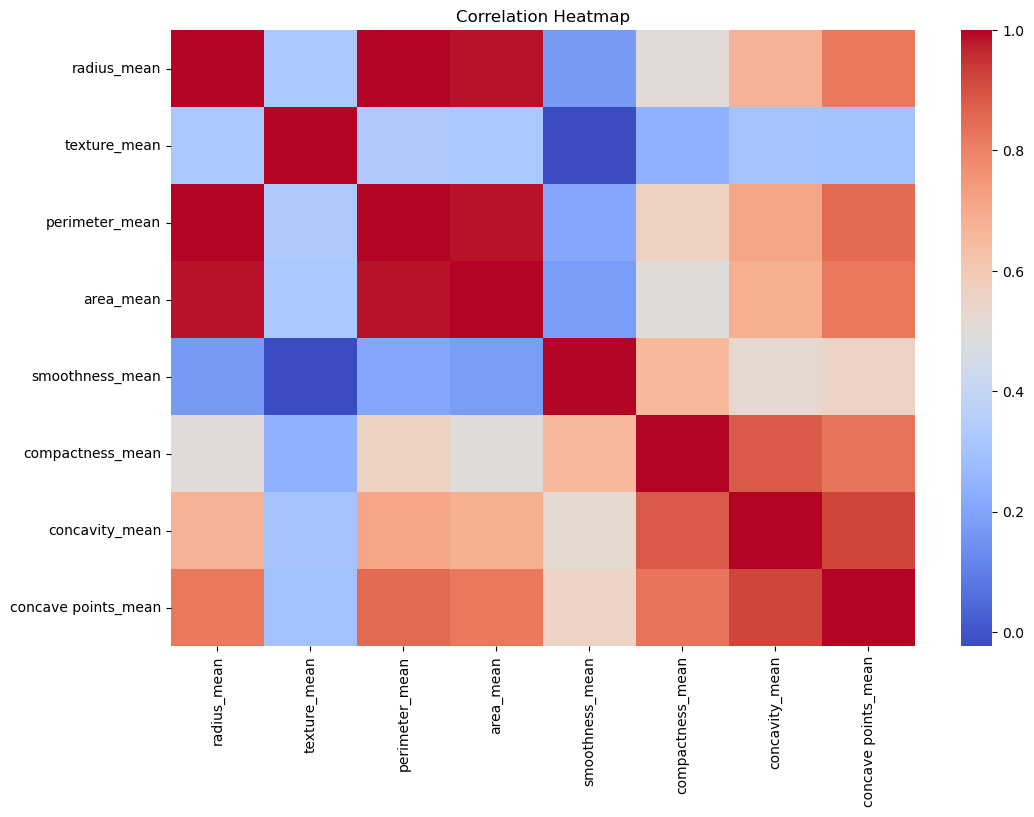

In [78]:
# 8. Calculate correlations (numeric only)
corr_matrix = df.drop(columns=['id','diagnosis']).corr()

# 9. Plot a correlation heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()


In [80]:
# Import libraries
# Program 3: Building a Simple Machine Learning Model
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv(r'C:\Users\pande\Searches\Desktop\breast_cancer.csv')

# Features and target
X = df.drop(['id','diagnosis'], axis=1)
y = df['diagnosis'].map({'M':1, 'B':0})   # Encode target

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Class distribution in train:\n", y_train.value_counts())


Training samples: 455
Testing samples: 114
Class distribution in train:
 diagnosis
0    285
1    170
Name: count, dtype: int64


In [82]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-Score :", f1_score(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy : 0.9385964912280702
Precision: 0.9069767441860465
Recall   : 0.9285714285714286
F1-Score : 0.9176470588235294

Confusion Matrix:
 [[68  4]
 [ 3 39]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.94      0.95        72
           1       0.91      0.93      0.92        42

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



In [85]:
# Program 4: Classification using Multiple Machine Learning Algorithms
# 1. Prepare the dataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load dataset
df = pd.read_csv(r'C:\Users\pande\Searches\Desktop\breast_cancer.csv')

# Features and target
X = df.drop(['id','diagnosis'], axis=1)
y = df['diagnosis'].map({'M':1, 'B':0})

# 2. Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Create four classification models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(kernel='linear', random_state=42)
}


In [86]:
# 5. Train each model + 6. Predict test labels + 7. Calculate metrics
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])

# 8. Compare results
results_df = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1-Score"])
print(results_df)

                    Model  Accuracy  Precision    Recall  F1-Score
0     Logistic Regression  0.938596   0.906977  0.928571  0.917647
1           Decision Tree  0.903509   0.860465  0.880952  0.870588
2           Random Forest  0.912281   0.900000  0.857143  0.878049
3  Support Vector Machine  0.929825   0.886364  0.928571  0.906977


In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

# Load dataset
# df = pd.read_csv("data-selected-columns breast.csv")
X = df.drop(['id','diagnosis'], axis=1)
y = df['diagnosis'].map({'M':1, 'B':0})

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Logistic Regression and assign to best_model
best_model = LogisticRegression(max_iter=1000)
best_model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [90]:
# Example patient data (raw values)
patient_data = [[17.99, 10.38, 122.8, 1001, 0.1184, 0.2776, 0.3001, 0.1471]]

 #Malignant sample from KAGGLE DATASET

# Scale patient data using same scaler
patient_data_scaled = scaler.transform(patient_data)

# Predict
prediction = best_model.predict(patient_data_scaled)

if prediction[0] == 1:
    print("Malignant (Cancerous)")
else:
    print("Benign (Non-Cancerous)")


Malignant (Cancerous)


In [105]:
# Example patient data (raw values)
patient_data = [[13.05,19.31,82.61,527.2,0.0806,0.03789,0.000692,0.004167

]]  # Benign sample from KAGGLE DATASET

# Scale patient data using same scaler
patient_data_scaled = scaler.transform(patient_data)

# Predict
prediction = best_model.predict(patient_data_scaled)

if prediction[0] == 1:
    print("Malignant (Cancerous)")
else:
    print("Benign (Non-Cancerous)")


Benign (Non-Cancerous)


In [107]:
# Example patient data (raw values)
patient_data = [[21.45,18.20,140.5,1450.0,0.1102,0.2103,0.2804,0.1502

]]  # Malignant  RANDOM DATASET FROM COPILOT sample 


# Scale patient data using same scaler
patient_data_scaled = scaler.transform(patient_data)

# Predict
prediction = best_model.predict(patient_data_scaled)

if prediction[0] == 1:
    print("Malignant (Cancerous)")
else:
    print("Benign (Non-Cancerous)")



Malignant (Cancerous)


In [108]:
# 12.80	14.50	85.6	520.0	0.0951	0.0702	0.0403	0.0301
# Example patient data (raw values)
patient_data = [[12.80,14.50,85.6,520.0,0.0951,0.0702,0.0403,0.0301

]]  # Benign  RANDOM DATASET FROM COPILOT sample 

# Scale patient data using same scaler
patient_data_scaled = scaler.transform(patient_data)

# Predict
prediction = best_model.predict(patient_data_scaled)

if prediction[0] == 1:
    print("Malignant (Cancerous)")
else:
    print("Benign (Non-Cancerous)")


Benign (Non-Cancerous)
